In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_core.tools import tool
from typing_extensions import TypedDict

# SQL 그래프 (tool로 사용될 그래프)
class SqlState(TypedDict):
    query: str
    result: str
    cancelled: bool  # 취소 상태 추가

def execute_query(state: SqlState):
    # HITL: 쿼리 실행 전 승인 요청
    user_decision = interrupt({
        "query": state["query"],
        "message": "이 쿼리를 실행하시겠습니까? (approve/cancel)"
    })
    
    # "cancel" 입력 시 그래프 중단
    if user_decision == "cancel":
        return {"result": "Query execution cancelled by user", "cancelled": True}
    
    # 승인된 경우 쿼리 실행
    result = f"Executed: {state['query']}"
    return {"result": result, "cancelled": False}

sql_builder = StateGraph(SqlState)
sql_builder.add_node("execute", execute_query)
sql_builder.add_edge(START, "execute")
sql_builder.add_edge("execute", END)
sql_graph = sql_builder.compile()

# SQL 그래프를 tool로 변환
@tool
def sql_tool(query: str) -> str:
    """SQL 쿼리를 실행하는 도구"""
    result = sql_graph.invoke({"query": query, "cancelled": False})
    return result["result"]

# 부모 에이전트 그래프
class AgentState(TypedDict):
    messages: list
    cancelled: bool  # 취소 상태 추적

def agent_node(state: AgentState):
    # 이미 취소된 경우 실행하지 않음
    if state.get("cancelled", False):
        return {"messages": state["messages"]}
    
    from langchain_openai import ChatOpenAI
    
    model = ChatOpenAI(model="gpt-4").bind_tools([sql_tool])
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def check_cancellation(state: AgentState):
    """취소 여부 확인"""
    # 마지막 메시지에서 취소 여부 확인
    last_message = state["messages"][-1] if state["messages"] else None
    if last_message and "cancelled" in str(last_message.content).lower():
        return "cancelled"
    return "continue"

agent_builder = StateGraph(AgentState)
agent_builder.add_node("agent", agent_node)
agent_builder.add_edge(START, "agent")

# 조건부 엣지: 취소 여부에 따라 분기
agent_builder.add_conditional_edges(
    "agent",
    check_cancellation,
    {
        "cancelled": END,  # 취소 시 즉시 종료
        "continue": END,   # 정상 완료
    }
)

# Checkpointer는 부모 그래프에만!
checkpointer = MemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

# 실행 예시
config = {"configurable": {"thread_id": "1"}}

# 1. 첫 실행 - interrupt 발생
result = agent.invoke(
    {"messages": [{"role": "user", "content": "DELETE FROM users 실행해줘"}], "cancelled": False}, 
    config
)
print("Interrupt:", result.get("__interrupt__"))

# 2-A. 취소하는 경우
result = agent.invoke(Command(resume="cancel"), config)
print("Result after cancel:", result)

# 2-B. 승인하는 경우 (새로운 thread로 다시 시작)
config2 = {"configurable": {"thread_id": "2"}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "SELECT * FROM users"}], "cancelled": False}, 
    config2
)
result = agent.invoke(Command(resume="approve"), config2)
print("Result after approve:", result)

Interrupt: None
Result after cancel: {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 58, 'total_tokens': 75, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-Cbo1qTCx3ghQQH8Rf8rLYVTrumBzx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--d02bfded-b17b-4c14-bc74-c09c1b7776fd-0', tool_calls=[{'name': 'sql_tool', 'args': {'query': 'DELETE FROM users'}, 'id': 'call_dkpxZxIasqItfo9kqexOChsS', 'type': 'tool_call'}], usage_metadata={'input_tokens': 58, 'output_tokens': 17, 'total_tokens': 75, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

=== SQL Graph ===


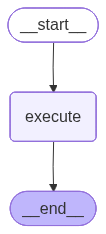

In [3]:
from IPython.display import Image, display

print("=== SQL Graph ===")
display(Image(sql_graph.get_graph().draw_mermaid_png()))

=== Agent Graph ===


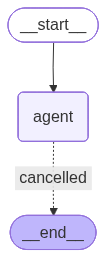

In [4]:
print("=== Agent Graph ===")
display(Image(agent.get_graph().draw_mermaid_png()))

In [6]:
# 또는 Mermaid 텍스트로 출력
print("\n=== SQL Graph (Mermaid) ===")
print(sql_graph.get_graph().draw_mermaid())

print("\n=== Agent Graph (Mermaid) ===")
print(agent.get_graph().draw_mermaid())



=== SQL Graph (Mermaid) ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	execute(execute)
	__end__([<p>__end__</p>]):::last
	__start__ --> execute;
	execute --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


=== Agent Graph (Mermaid) ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -. &nbsp;cancelled&nbsp; .-> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

